# Linear regression with gradient descent

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Understand linear regression in the context of gradient descent;
- Understand the cost function and its role in gradient descent;
- Underatand the impact of number of iterations and learning rates on gradients descent;
- Understand the implications of non-convex cost functions.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


## Top-down view onto this notebook
This assignment uses a toy dataset to familiarize you with linear regression using gradient descent. Specifically:
1. In exercise 1, you will familiarize yourself with the toy dataset;
2. In exercise 2, you will implement the cost-function for linear regression;
3. In exercise 3, you will use gradient descent and analyse effects of several hyper parameters such as the number of iterations as well as the learning rate;
4. In exercise 4 (optional), you will learn about a limitation of gradient descent.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model


## Exercise 1: Explore the dataset

Ordinary Least Squares Linear Regression can be calculated by the analytical solution to estimate the coefficients $\hat{\boldsymbol w}$. In this assignment you will solve the same optimization problem using a standard numerical optimization method called Gradient Descent. Let's first explore our dataset

1. Visualize the given data X and y which will be used to fit a linear regression model. How many feature dimensions are contained? **Hint:** In this assignment, the augmented notation for the data $\mathbf{X}$ is used such that the estimated coefficients $\hat{\boldsymbol w}$ fit the augmented model $f(\mathbf X) = \mathbf X \hat{\boldsymbol w}$
2. Split the given data X and y into train (first 100 data points) and test set (last 200 data points).


In [2]:
# Load the data
X = np.loadtxt('data/GD_dataset1.data') # shape (N, 2) in augmented form
y = np.loadtxt('data/GD_dataset1.labels')

Shape of X: (300, 2)
[[ 0.72909  1.     ]
 [-0.14963  1.     ]
 [ 2.24089  1.     ]
 [ 0.37915  1.     ]
 [-0.48103  1.     ]]
Shape of y: (300,)


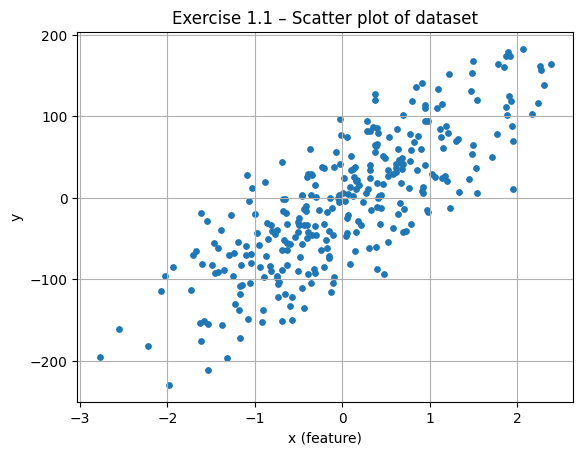

Train shapes: (100, 2) (100,)
Test shapes : (200, 2) (200,)


In [3]:
# Answer here
# There is only one 1-D feature and 1 constant column of 
# ones due to augmented notation

print("Shape of X:", X.shape)
# print(X[:,0].shape)
print(X[0:5])
print("Shape of y:", y.shape)

plt.figure()
plt.scatter(X[:, 0], y, s=15)
plt.xlabel("x (feature)")
plt.ylabel("y")
plt.title("Exercise 1.1 – Scatter plot of dataset")
plt.grid(True)
plt.show()

# Split into train and test sets
N_train = 100
X_train = X[:N_train]
y_train = y[:N_train]

X_test = X[N_train:]
y_test = y[N_train:]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes :", X_test.shape, y_test.shape)


## Exercise 2: Explore the behaviour of the cost function

In order to compute the coefficients $\hat{\boldsymbol w}$ for the OLS Linear Regression, we need a cost function $J(\mathbf{w})$.

1. Look up the definition of the cost function for ordinary least-squares (OLS) linear regression and implement it in the function `cost_function()`. The function should return a single scalar which is the evaluation of the cost function $J(\mathbf{w})$.
2. Evaluate your implemented cost function $J(\mathbf{w})$ by varying the parameter $w_{0}\in[-500, 600]$ and you can set the bias term $w_{1}=0$), using the training data $\mathbf{X}_{train}$ and $\mathbf{y}_{train}$. Plot the resulting cost function.


In [4]:
# Answer here

def cost_function(X, y, w):
    """cost_function(X, y, w) computes the MSE cost using w as the
    coefficients for linear regression to fit the data points in X and y
    
    Input:
        X: array with data matrix X
        y: observed output vector
        w: regression weights (compact form)

    Return: 
        J: scalar cost

    """
    # Number of training examples
    N = X.shape[0]

    y_hat = X @ w          # predicted outputs
    residuals = y_hat - y  # vector of errors

    # Calculate the MSE cost with the given parameters
    J = (1.0 / (2 * N)) * np.sum(residuals ** 2)
    
    return J

The prediction of the linear model is $\hat{y} = X w$. The OLS cost (half mean-squared error) is

$
J(w) = \frac{1}{2N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2
      = \frac{1}{2N} \lVert Xw - y \rVert_2^2.
$

The factor $ \tfrac{1}{2} $ is conventional and simplifies gradients.



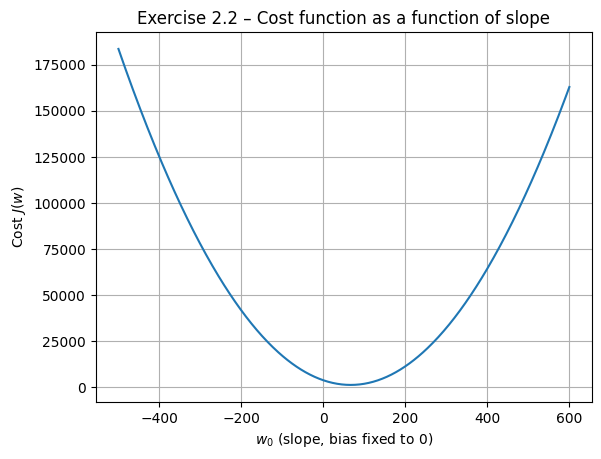

It is a convex parabola


In [5]:
# We vary the slope (coefficient for the true feature) and set the bias to 0.
# For plotting, we assume the coefficient ordering is [feature, bias].
# If in your data the order is [bias, feature], simply swap how w is constructed.

w0_values = np.linspace(-500, 600, 500)  # 500 points in [-500, 600)
J_values = []

feat_idx = 0
bias_idx = 1

for w0 in w0_values:
    # w = [w0 (slope), 1 (bias)]
    w_vec = np.zeros(X_train.shape[1])
    w_vec[feat_idx] = w0   # slope on the feature column
    w_vec[bias_idx] = 0.0  # bias fixed at 0
    J_values.append(cost_function(X_train, y_train, w_vec))

J_values = np.array(J_values)

plt.figure()
plt.plot(w0_values, J_values)
plt.xlabel(r"$w_0$ (slope, bias fixed to 0)")
plt.ylabel(r"Cost $J(w)$")
plt.title("Exercise 2.2 – Cost function as a function of slope")
plt.grid(True)
plt.show()
print("It is a convex parabola")

## Exercise 3: Gradient descent

Above, you have already explored the full landscape of the cost function. If we now assume that a single evaluation of $J$ is (e.g. computationally) expensive, then you want to use a strategy with as few evaluations as possible to find $\boldsymbol w^{*}$ with the minimum cost $J({\boldsymbol w^{*}})$. To do so, we will now use an iterative approach to find $J(\boldsymbol w^{*})$ of the linear regression coefficients $\boldsymbol w$. The convergence of the utilized gradient descent algorithm shall be investigated with respect to its parameters (learning rate $\eta$, number of iterations $N_{iter}$) and its estimated coefficients $\hat{\boldsymbol w}$ shall be compared to those the analytical solution of the OLS linear regression.

1. Lookup the scikit-learn toolbox implementation of the analytical OLS linear regression model or use your code of the previous assignment. Train the model on the given training data $\mathbf{X}_{train}$ and $\mathbf{y}_{train}$ and print the estimated coefficients $\hat{\boldsymbol w}$ of the analytical solution.
2. Inspect the given function `gradient_descent()`. Use it to optimize the cost function by varying the number of iteration steps as $N_{iter}\in\{2,5,10,20,40\}$. Keep the learning rate fixed at $\eta=0.1$ and use the given starting value $\boldsymbol w_{start}=(-400,0)^{T}$.
3. Create a scatter plot of the test data $\mathbf{X}_{test}$ and $\mathbf{y}_{test}$ and add the corresponding linear regression fit for each parameter configuration $N_{iter}$ to the plot. In addition, add the linear regression fit that you gained from the analytical solution in step 1.
4. Plot the cost function of the previous exercise again and add the five evalutated cost function values gained by varying  $N_{iter}$.
5. What can you observe from the two plots for an increased number of iterations $N_{iter}$?
6. Assume you apply your best linear regression model $\hat{\mathbf{w}}$ to your *test* data and compare the test error to your training error. What do you expect and why? What is your expectation if you would do the same with the analytical solution of the OLS linear regression model? How do you expect that the error of the numeric (gradient descent) solution compares to that of the analytic solution?
5. Repeat steps 2-4 by varying the learning rate $\eta \in \{10^{-4}, 10^{-2}, 10^{-1}, 1\}$, but fix the number of iterations $N_{iter}=5$. Use the same $\boldsymbol w_{start}$ as in step 2.
6. What happens if you choose a learning rate $\eta >> 1$ ?

In [6]:
def gradient_descent(X, y, eta, N_iterations, w_start=np.array([0, 0])):
    """gradient_descent(X, y, eta, N_iterations, w_start) runs batch 
    gradient descent optimization to fit a regression model 
    y_est = beta * x"
    
    Input:
        X: array with data matrix X
        y: vector with observed output
        eta: learning rate of gradient descent
        N_iterations: total number of iterations for the optimization
        w_start: initial configuration of coefficients
        
    Return:  
        w: array with optimal parameter set
        cost_history: array of size N_iterations with history of cost function
    """
    cost_history = np.zeros(N_iterations)
    m = X.shape[0]
    
    # Initialize the coefficients
    w = w_start
    
    # Loop iterations
    for iteration in range(N_iterations):
        
        # Compute gradient
        hypothesis = X.dot(w)
        loss = hypothesis - y
        gradient = X.T.dot(loss)/m
        
        # Update weights
        w = w - eta * gradient
        
        # Save losses
        cost = cost_function(X, y, w)
        cost_history[iteration] = cost
    
    return w, cost_history


In [7]:
# Ex. 3.1

# We use fit_intercept=False because X already contains a bias column.
ols = linear_model.LinearRegression(fit_intercept=False)
ols.fit(X_train, y_train)

w_hat_analytic = ols.coef_.ravel()  # shape (2,)

print("Analytical OLS coefficients (w_hat):", w_hat_analytic)


Analytical OLS coefficients (w_hat): [66.94283347 -8.64164235]


In [8]:
#  Parameters for this step
eta_fixed = 0.1
N_iters_list = [2, 5, 10, 20, 40]
w_start = np.array([-400.0, 0.0])

w_solutions = {}
cost_histories = {}

for N_it in N_iters_list:
    w_opt, cost_hist = gradient_descent(X_train, y_train,
                                        eta=eta_fixed,
                                        N_iterations=N_it,
                                        w_start=w_start)
    w_solutions[N_it] = w_opt
    cost_histories[N_it] = cost_hist
    print(f"N_iter = {N_it:2d}, w = {w_opt}, final cost = {cost_hist[-1]:.3f}")

N_iter =  2, w = [-300.11171849    2.80219732], final cost = 77603.355
N_iter =  5, w = [-188.94903636    4.38242112], final cost = 38369.184
N_iter = 10, w = [-73.43042769   3.39159868], final cost = 12465.614
N_iter = 20, w = [24.56137725 -1.72928921], final cost = 2328.101
N_iter = 40, w = [63.01929261 -7.26468511], final cost = 1309.844


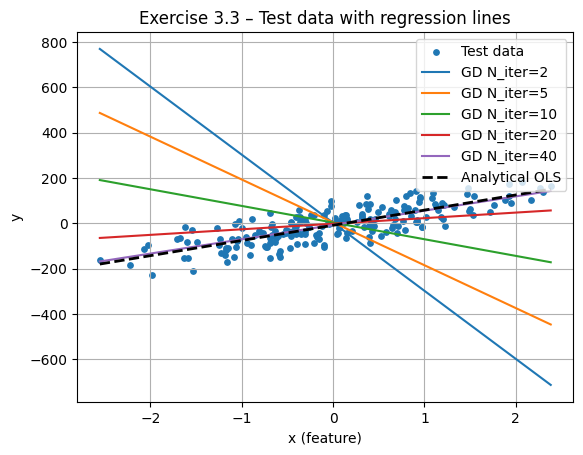

In [9]:
# 3.3
x_test = X_test[:, feat_idx]  # feature values for plotting

# Sort test points so that lines look smooth
sort_idx = np.argsort(x_test)
x_sorted = x_test[sort_idx]
X_test_sorted = X_test[sort_idx]

plt.figure()
plt.scatter(x_test, y_test, s=15, label="Test data")

# Add lines for each gradient descent configuration
for N_it in N_iters_list:
    w = w_solutions[N_it]
    y_pred = X_test_sorted @ w
    plt.plot(x_sorted, y_pred, label=f"GD N_iter={N_it}")

# Add line for analytical OLS solution
y_pred_analytic = X_test_sorted @ w_hat_analytic
plt.plot(x_sorted, y_pred_analytic, 'k--', linewidth=2,
         label="Analytical OLS")

plt.xlabel("x (feature)")
plt.ylabel("y")
plt.title("Exercise 3.3 – Test data with regression lines")
plt.grid(True)
plt.legend()
plt.show()


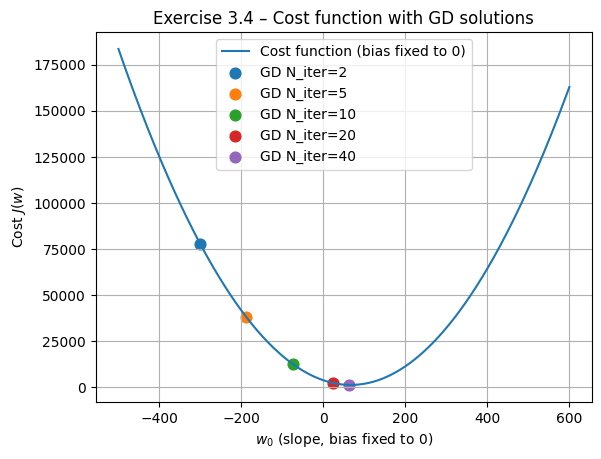

In [10]:
# Reuse w0_values and J_values from Exercise 2.2

plt.figure()
plt.plot(w0_values, J_values, label="Cost function (bias fixed to 0)")

# Overlay points for each GD solution (projecting onto slope axis)
for N_it in N_iters_list:
    w = w_solutions[N_it]
    w0_feat = w[feat_idx]     # slope component
    # For comparability we set bias=0 when evaluating on this 1D slice of J
    w_for_J = np.zeros_like(w)
    w_for_J[feat_idx] = w0_feat
    J_w = cost_function(X_train, y_train, w_for_J)
    plt.scatter(w0_feat, J_w, s=60, label=f"GD N_iter={N_it}")

plt.xlabel(r"$w_0$ (slope, bias fixed to 0)")
plt.ylabel(r"Cost $J(w)$")
plt.title("Exercise 3.4 – Cost function with GD solutions")
plt.grid(True)
plt.legend()
plt.show()


# Ex. 3.5
With few iterations (2–5), gradient descent is still far from the optimum.
This is visible in both plots:
* The regression lines (blue, orange) are very wrong on the test data.
* On the cost curve, those points sit far on the left with high cost. With more iterations (10–20–40), GD moves steadily toward the minimum:
* Regression lines approach the analytical OLS line.
* Cost points move down the parabola toward the minimum.

By ~20–40 iterations, GD is very close to the true optimum. The slope sits near the bottom of the parabola and the regression lines nearly overlap with the analytical one.

Conclusion:
More iterations → lower cost → parameters closer to OLS → regression line more accurate.

# Ex 3.6
This is a simple linear model, so overfitting is minimal. Training and test errors should be very similar. The analytical solution is the optimal solution, so it gives the lowest possible error.

Gradient descent:
* With many iterations, it converges almost exactly to the analytical solution → same train/test error.
* With few iterations, it is still far from the optimum → higher train and test error.

Conclusion:
OLS has the best (lowest) error.
GD matches it only once it converges; before that, it underfits.

eta = 0.0001, w = [-3.99735292e+02  8.11210793e-03], final cost = 124721.756
eta = 0.01, w = [-374.11825047    0.76797225], final cost = 111525.729
eta = 0.1, w = [-188.94903636    4.38242112], final cost = 38369.184
eta = 1, w = [66.97814658 -8.62938845], final cost = 1300.448


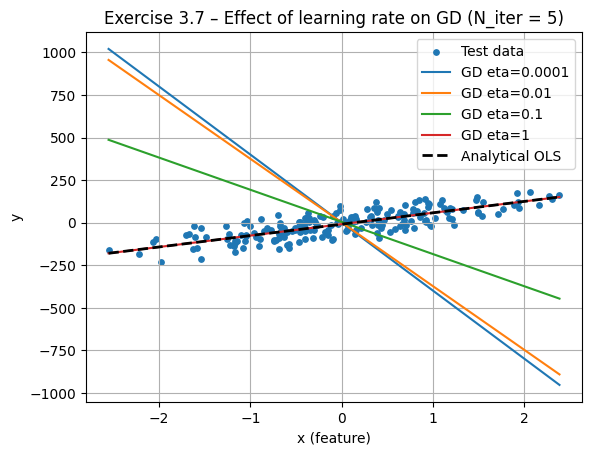

In [12]:
# Ex. 3.7

etas = [1e-4, 1e-2, 1e-1, 1.0]
N_iter_fixed = 5

w_eta = {}
cost_eta = {}

for eta in etas:
    w_opt, cost_hist = gradient_descent(X_train, y_train,
                                        eta=eta,
                                        N_iterations=N_iter_fixed,
                                        w_start=w_start)
    w_eta[eta] = w_opt
    cost_eta[eta] = cost_hist
    print(f"eta = {eta:g}, w = {w_opt}, final cost = {cost_hist[-1]:.3f}")


x_test = X_test[:, feat_idx]
sort_idx = np.argsort(x_test)
x_sorted = x_test[sort_idx]
X_test_sorted = X_test[sort_idx]

plt.figure()
plt.scatter(x_test, y_test, s=15, label="Test data")

for eta in etas:
    w = w_eta[eta]
    y_pred = X_test_sorted @ w
    plt.plot(x_sorted, y_pred, label=f"GD eta={eta:g}")

# Analytical OLS line for reference
y_pred_analytic = X_test_sorted @ w_hat_analytic
plt.plot(x_sorted, y_pred_analytic, 'k--', linewidth=2,
         label="Analytical OLS")

plt.xlabel("x (feature)")
plt.ylabel("y")
plt.title("Exercise 3.7 – Effect of learning rate on GD (N_iter = 5)")
plt.grid(True)
plt.legend()
plt.show()


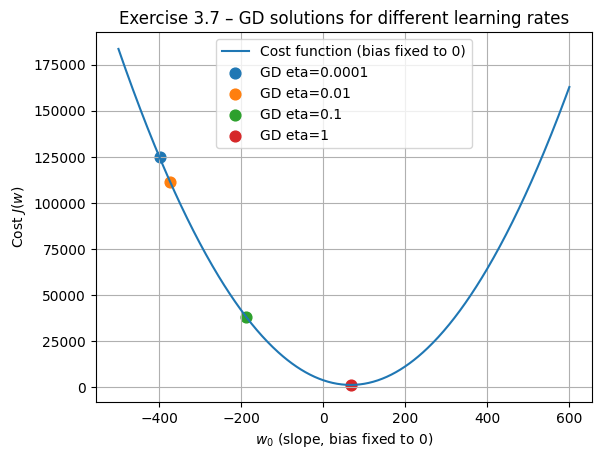

In [13]:
plt.figure()
plt.plot(w0_values, J_values, label="Cost function (bias fixed to 0)")

for eta in etas:
    w = w_eta[eta]
    w0_feat = w[feat_idx]
    w_for_J = np.zeros_like(w)
    w_for_J[feat_idx] = w0_feat
    J_w = cost_function(X_train, y_train, w_for_J)
    plt.scatter(w0_feat, J_w, s=60, label=f"GD eta={eta:g}")

plt.xlabel(r"$w_0$ (slope, bias fixed to 0)")
plt.ylabel(r"Cost $J(w)$")
plt.title("Exercise 3.7 – GD solutions for different learning rates")
plt.grid(True)
plt.legend()
plt.show()


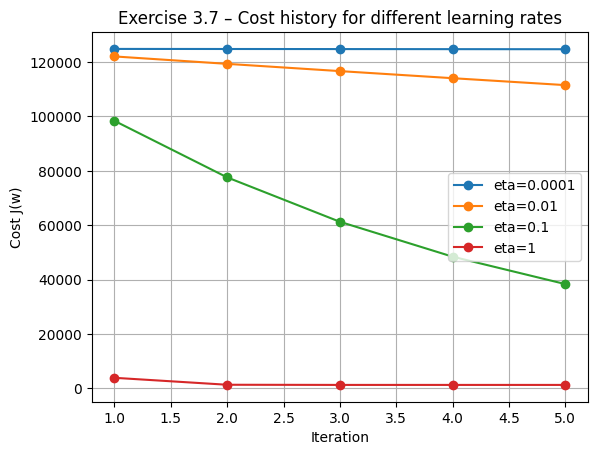

In [14]:
plt.figure()
for eta in etas:
    plt.plot(range(1, N_iter_fixed + 1), cost_eta[eta],
             marker='o', label=f"eta={eta:g}")

plt.xlabel("Iteration")
plt.ylabel("Cost J(w)")
plt.title("Exercise 3.7 – Cost history for different learning rates")
plt.grid(True)
plt.legend()
plt.show()


# Ex. 3.8
If the learning rate η>1:

* Steps become too large, so GD overshoots the minimum.
* The updates start to oscillate or diverge instead of moving downhill.
* The cost will typically increase, and the parameters can blow up.

Conclusion:
Learning rates above 1 make gradient descent unstable or divergent for this quadratic cost.

## (Optional) Exercise 4: Pitfalls of gradient descent

The use of iterative optimization methods (such as gradient descent) is not restricted to linear models, and for some problems an analytical solution may not even exist (or has not been found yet). For this reason, many complex Machine Learning models are trained using iterative optimization.

However, iterative optimization of more complex problems comes at a price... Let's take a look at such situations by choosing a different model class (sine instead of linear functions)!

1. Visualize the given data set. Note that the second dimension of $\mathbf{X}$ contains ones to make use of the augmented notation (like in the previous exercises).
2. Modify your MSE cost function of the previous exercises such that you can fit a model $f(\mathbf{x})=\sin(\mathbf{w}^T\mathbf{x})$.  
3. Set $w_{1}=1$ and evaluate the cost function $J(w_{0})$ for values $w_{0}\in[-4\pi,4\pi]$. Visualize your results.
4. What happens if you now apply the iterative gradient descent approach?


In [ ]:
# Load the data
X = np.loadtxt('data/GD_dataset2.data')
y = np.loadtxt('data/GD_dataset2.labels')


In [ ]:
# Answer here

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here

Petros 1-3